In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import scipy.stats as stats
from utils import *

# 1 Load Data

In [19]:
# load summer trajectory
summer_traj = np.load('data/solar_summer_winter.npz')['summer']

In [20]:
# load predictions for chronos on summer trajectories
x = np.load("data/predictions/chronos/chronos2_solar_summer.npz")['yhat_q']

# load predictions for chronos on winter trajectories
x2 = np.load("data/predictions/chronos/chronos2_solar_winter.npz")['yhat_q']

# load predictions for timesfm predictions for solar summer
x3 = np.load("data/predictions/timesfm/timesfm_solar_summer.npz")['yhat']

# load predictions for timesfm predictions for solar winter
x4 = np.load("data/predictions/timesfm/timesfm_solar_winter.npz")['yhat']

# 2 Mean Absolute Error

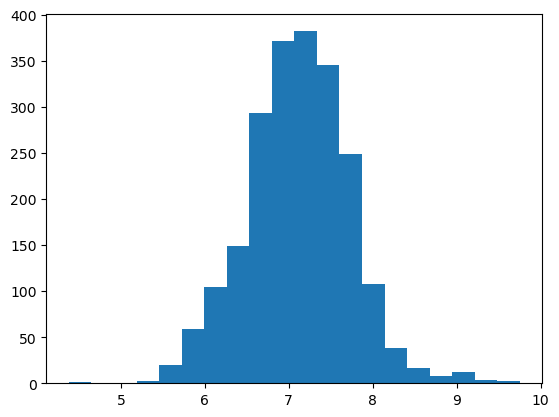

In [21]:
maes_x = calculate_mae("data/predictions/chronos/chronos2_solar_summer.npz", season='summer')

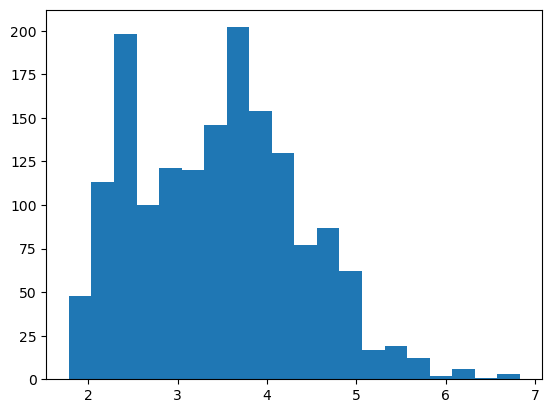

In [22]:
# calculate maes for chronos on winter trajectories
mae_x2 = calculate_mae("data/predictions/chronos/chronos2_solar_winter.npz", season='winter')

Error calculating MAE for iteration 1967
Error calculating MAE for iteration 1968
Error calculating MAE for iteration 1969
Error calculating MAE for iteration 1970
Error calculating MAE for iteration 1971
Error calculating MAE for iteration 1972
Error calculating MAE for iteration 1973
Error calculating MAE for iteration 1974
Error calculating MAE for iteration 1975
Error calculating MAE for iteration 1976
Error calculating MAE for iteration 1977
Error calculating MAE for iteration 1978
Error calculating MAE for iteration 1979
Error calculating MAE for iteration 1980
Error calculating MAE for iteration 1981
Error calculating MAE for iteration 1982
Error calculating MAE for iteration 1983
Error calculating MAE for iteration 1984
Error calculating MAE for iteration 1985
Error calculating MAE for iteration 1986
Error calculating MAE for iteration 1987
Error calculating MAE for iteration 1988
Error calculating MAE for iteration 1989
Error calculating MAE for iteration 1990
Error calculatin

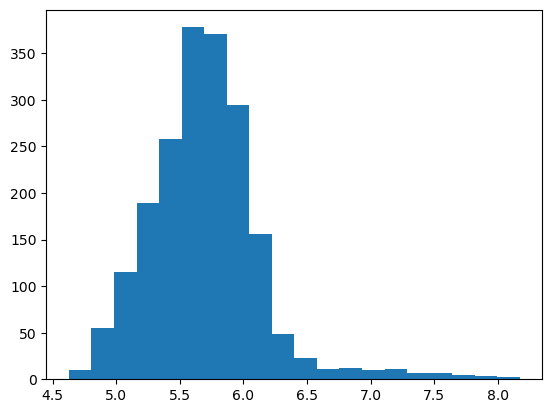

In [23]:
# mae for timesfm solar summer
mae_x3 = calculate_mae("data/predictions/timesfm/timesfm_solar_summer.npz", season='summer')

Error calculating MAE for iteration 1420
Error calculating MAE for iteration 1421
Error calculating MAE for iteration 1422
Error calculating MAE for iteration 1423
Error calculating MAE for iteration 1424
Error calculating MAE for iteration 1425
Error calculating MAE for iteration 1426
Error calculating MAE for iteration 1427
Error calculating MAE for iteration 1428
Error calculating MAE for iteration 1429
Error calculating MAE for iteration 1430
Error calculating MAE for iteration 1431
Error calculating MAE for iteration 1432
Error calculating MAE for iteration 1433
Error calculating MAE for iteration 1434
Error calculating MAE for iteration 1435
Error calculating MAE for iteration 1436
Error calculating MAE for iteration 1437
Error calculating MAE for iteration 1438
Error calculating MAE for iteration 1439
Error calculating MAE for iteration 1440
Error calculating MAE for iteration 1441
Error calculating MAE for iteration 1442
Error calculating MAE for iteration 1443
Error calculatin

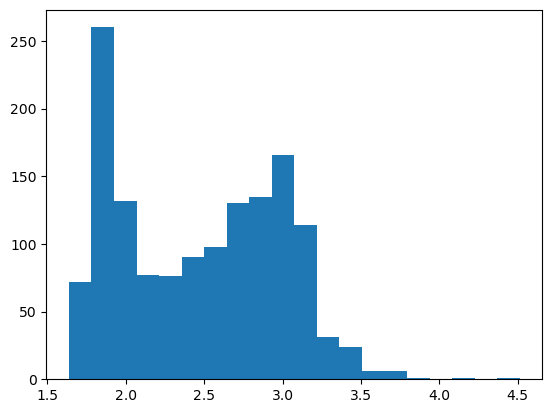

In [24]:
# calculate mae for timesfm solar winter
mae_x4 = calculate_mae("data/predictions/timesfm/timesfm_solar_winter.npz", season='winter')

In [25]:
# get mean and std of maes for x
mean_mae_x = np.mean(maes_x)
std_mae_x = np.std(maes_x)

print(f"Mean MAE for Chronos2 Solar Summer: {mean_mae_x:.4f} ± {std_mae_x:.4f}")

# get mean and std of maes for x2
mean_mae_x2 = np.mean(mae_x2)
std_mae_x2 = np.std(mae_x2)

print(f"Mean MAE for Chronos2 Solar Winter: {mean_mae_x2:.4f} ± {std_mae_x2:.4f}")

# get mean and std of maes for x3
mean_mae_x3 = np.mean(mae_x3)
std_mae_x3 = np.std(mae_x3)

print(f"Mean MAE for TimesFM Solar Summer: {mean_mae_x3:.4f} ± {std_mae_x3:.4f}")

# get mean and std of maes for x4
mean_mae_x4 = np.mean(mae_x4)
std_mae_x4 = np.std(mae_x4)

print(f"Mean MAE for TimesFM Solar Winter: {mean_mae_x4:.4f} ± {std_mae_x4:.4f}")

Mean MAE for Chronos2 Solar Summer: 7.1185 ± 0.6120
Mean MAE for Chronos2 Solar Winter: 3.4573 ± 0.9140
Mean MAE for TimesFM Solar Summer: 5.7005 ± 0.4435
Mean MAE for TimesFM Solar Winter: 2.4725 ± 0.5151


# 3 Wasserstein Distance of True and Predicted Power Spectra

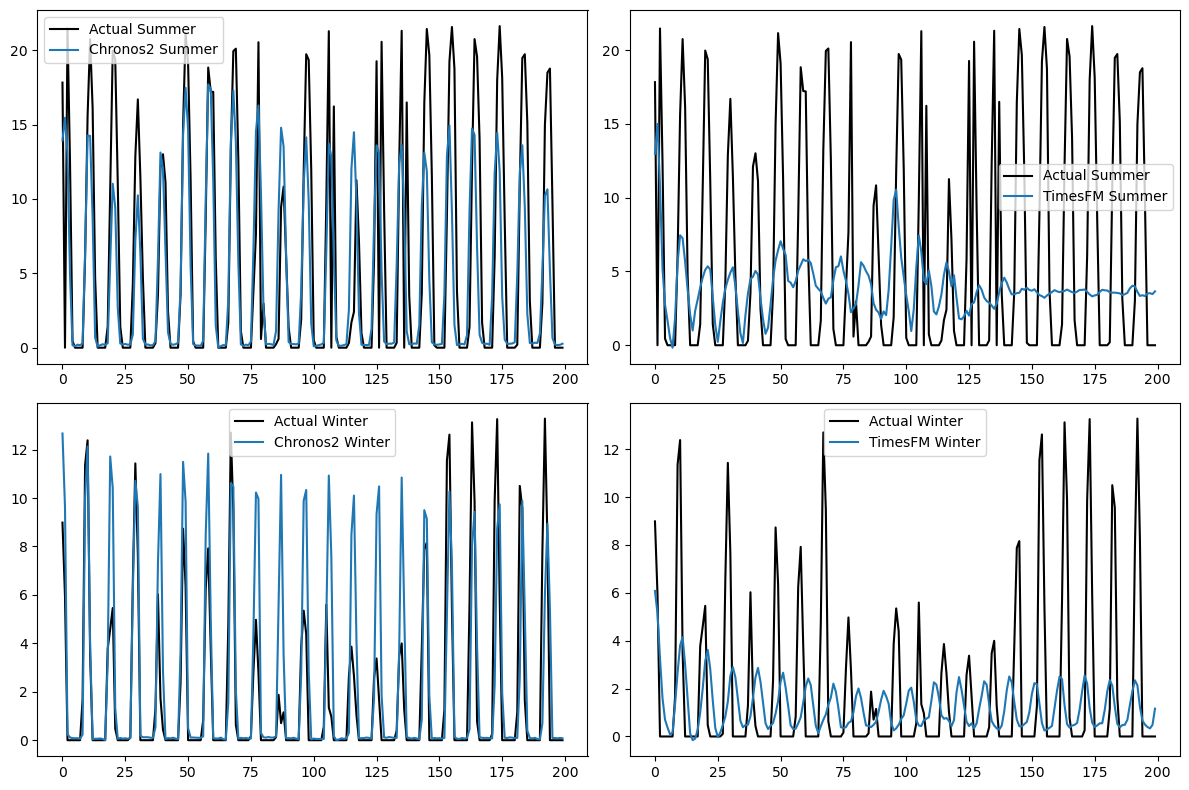

In [26]:
# plot first predicted vs actual trajectory

summer_traj = np.load('data/solar_summer_winter.npz')['summer']
winter_traj = np.load('data/solar_summer_winter.npz')['winter']


# plot all 4 predictions in sublpots with actual trajectory
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(summer_traj[100:300], label='Actual Summer', color='black')
plt.plot(x[0, :, :], label='Chronos2 Summer');
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(summer_traj[100:300], label='Actual Summer', color='black')
plt.plot(x3[0, :], label='TimesFM Summer');
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(winter_traj[100:300], label='Actual Winter', color='black')
plt.plot(x2[0, :, :], label='Chronos2 Winter');
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(winter_traj[100:300], label='Actual Winter', color='black')
plt.plot(x4[0, :], label='TimesFM Winter');
plt.legend()
plt.tight_layout()



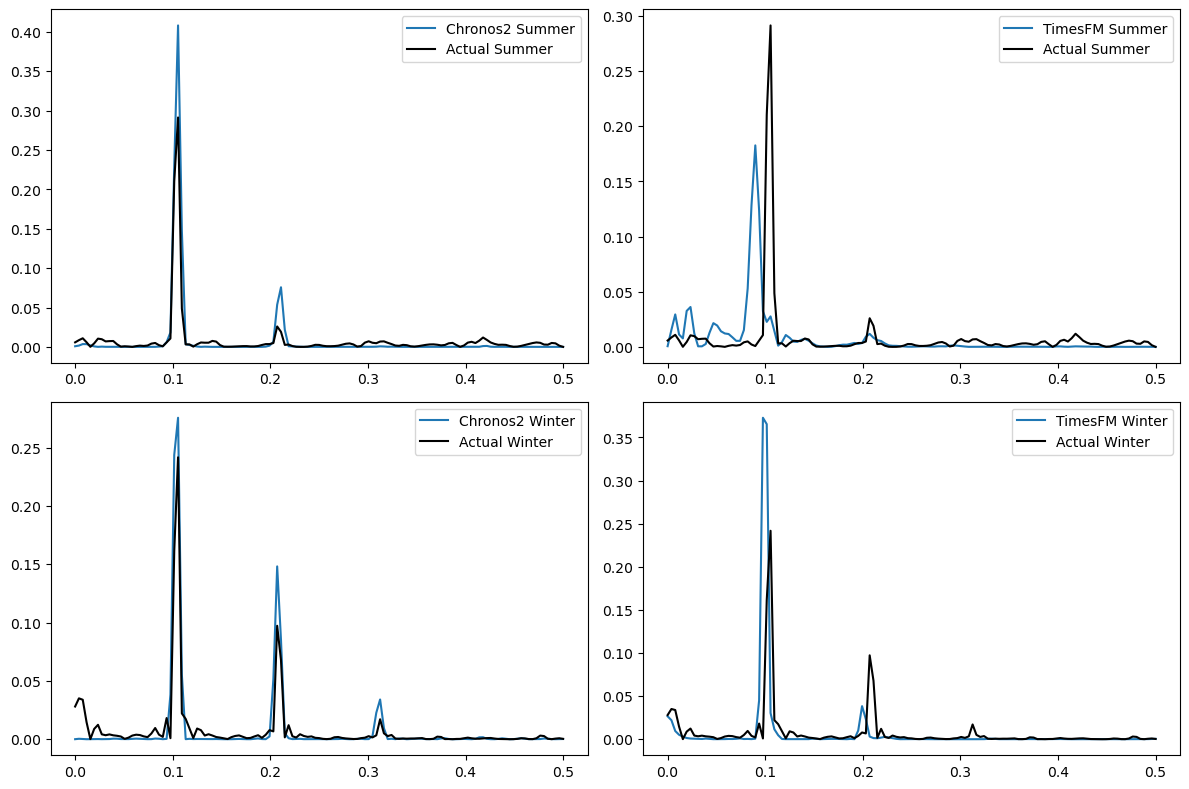

In [27]:
# plot of true and predicted power spectra by model and season

f1, P1 = power_spectrum_1s(x[0, :, 0])
f2, P2 = power_spectrum_1s(x2[0, :, 0])
f3, P3 = power_spectrum_1s(x3[0, :])
f4, P4 = power_spectrum_1s(x4[0, :])

f_sum, P_sum = power_spectrum_1s(summer_traj[100:300])
f_win, P_win = power_spectrum_1s(winter_traj[100:300])

# create subplots with power spectra of predictions and actual trajectories
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.plot(f1, P1, label='Chronos2 Summer')
plt.plot(f_sum, P_sum, label='Actual Summer', color='black')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(f3, P3, label='TimesFM Summer')
plt.plot(f_sum, P_sum, label='Actual Summer', color='black')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(f2, P2, label='Chronos2 Winter')
plt.plot(f_win, P_win, label='Actual Winter', color='black')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(f4, P4, label='TimesFM Winter')
plt.plot(f_win, P_win, label='Actual Winter', color='black')
plt.legend()
plt.tight_layout()


In [28]:
# print wasserstein distance between power spectra of predictions and actual trajectories
wd_sum_chronos = wasserstein_1d_on_grid(f1, P1, P_sum)
wd_sum_timesfm = wasserstein_1d_on_grid(f3, P3, P_sum)
wd_win_chronos = wasserstein_1d_on_grid(f2, P2, P_win)
wd_win_timesfm = wasserstein_1d_on_grid(f4, P4, P_win)
print(f"Wasserstein distance for Chronos2 Summer: {wd_sum_chronos:.4f}")
print(f"Wasserstein distance for TimesFM Summer: {wd_sum_timesfm:.4f}")
print(f"Wasserstein distance for Chronos2 Winter: {wd_win_chronos:.4f}")
print(f"Wasserstein distance for TimesFM Winter: {wd_win_timesfm:.4f}")

Wasserstein distance for Chronos2 Summer: 0.0547
Wasserstein distance for TimesFM Summer: 0.0757
Wasserstein distance for Chronos2 Winter: 0.0247
Wasserstein distance for TimesFM Winter: 0.0430


Chronos seems to preserve the power spectrum better than TimesFM, especially for the winter season. This is in line with insights from CT3.

Error calculating Wasserstein distance for iteration 2038
Error calculating Wasserstein distance for iteration 2039
Error calculating Wasserstein distance for iteration 2040
Error calculating Wasserstein distance for iteration 2041
Error calculating Wasserstein distance for iteration 2042
Error calculating Wasserstein distance for iteration 2043
Error calculating Wasserstein distance for iteration 2044
Error calculating Wasserstein distance for iteration 2045
Error calculating Wasserstein distance for iteration 2046
Error calculating Wasserstein distance for iteration 2047
Error calculating Wasserstein distance for iteration 2048
Error calculating Wasserstein distance for iteration 2049
Error calculating Wasserstein distance for iteration 2050
Error calculating Wasserstein distance for iteration 2051
Error calculating Wasserstein distance for iteration 2052
Error calculating Wasserstein distance for iteration 2053
Error calculating Wasserstein distance for iteration 2054
Error calculat

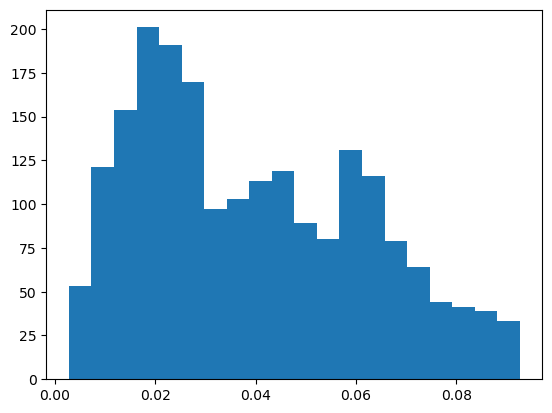

In [29]:
x1_wd = calculate_wasserstein("data/predictions/chronos/chronos2_solar_summer.npz", season='summer')


Error calculating Wasserstein distance for iteration 1491
Error calculating Wasserstein distance for iteration 1492
Error calculating Wasserstein distance for iteration 1493
Error calculating Wasserstein distance for iteration 1494
Error calculating Wasserstein distance for iteration 1495
Error calculating Wasserstein distance for iteration 1496
Error calculating Wasserstein distance for iteration 1497
Error calculating Wasserstein distance for iteration 1498
Error calculating Wasserstein distance for iteration 1499
Error calculating Wasserstein distance for iteration 1500
Error calculating Wasserstein distance for iteration 1501
Error calculating Wasserstein distance for iteration 1502
Error calculating Wasserstein distance for iteration 1503
Error calculating Wasserstein distance for iteration 1504
Error calculating Wasserstein distance for iteration 1505
Error calculating Wasserstein distance for iteration 1506
Error calculating Wasserstein distance for iteration 1507
Error calculat

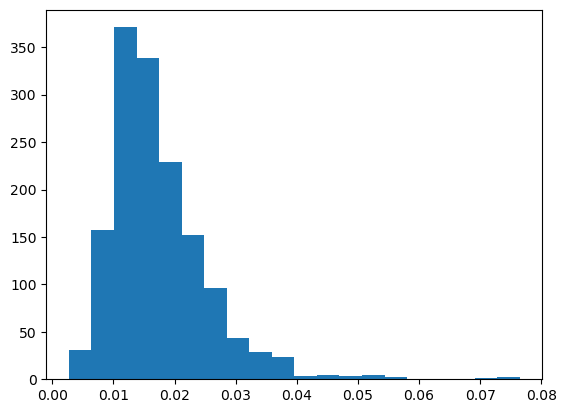

In [30]:
x2_wd = calculate_wasserstein("data/predictions/chronos/chronos2_solar_winter.npz", season='winter')

Error calculating Wasserstein distance for iteration 2038
Error calculating Wasserstein distance for iteration 2039
Error calculating Wasserstein distance for iteration 2040
Error calculating Wasserstein distance for iteration 2041
Error calculating Wasserstein distance for iteration 2042
Error calculating Wasserstein distance for iteration 2043
Error calculating Wasserstein distance for iteration 2044
Error calculating Wasserstein distance for iteration 2045
Error calculating Wasserstein distance for iteration 2046
Error calculating Wasserstein distance for iteration 2047
Error calculating Wasserstein distance for iteration 2048
Error calculating Wasserstein distance for iteration 2049
Error calculating Wasserstein distance for iteration 2050
Error calculating Wasserstein distance for iteration 2051
Error calculating Wasserstein distance for iteration 2052
Error calculating Wasserstein distance for iteration 2053
Error calculating Wasserstein distance for iteration 2054
Error calculat

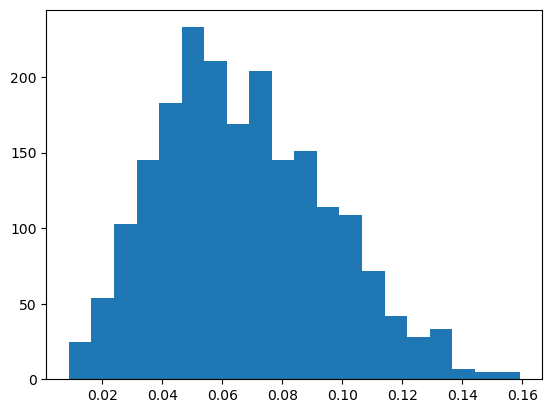

In [31]:
x3_wd = calculate_wasserstein("data/predictions/timesfm/timesfm_solar_summer.npz", season='summer')

Error calculating Wasserstein distance for iteration 1491
Error calculating Wasserstein distance for iteration 1492
Error calculating Wasserstein distance for iteration 1493
Error calculating Wasserstein distance for iteration 1494
Error calculating Wasserstein distance for iteration 1495
Error calculating Wasserstein distance for iteration 1496
Error calculating Wasserstein distance for iteration 1497
Error calculating Wasserstein distance for iteration 1498
Error calculating Wasserstein distance for iteration 1499
Error calculating Wasserstein distance for iteration 1500
Error calculating Wasserstein distance for iteration 1501
Error calculating Wasserstein distance for iteration 1502
Error calculating Wasserstein distance for iteration 1503
Error calculating Wasserstein distance for iteration 1504
Error calculating Wasserstein distance for iteration 1505
Error calculating Wasserstein distance for iteration 1506
Error calculating Wasserstein distance for iteration 1507
Error calculat

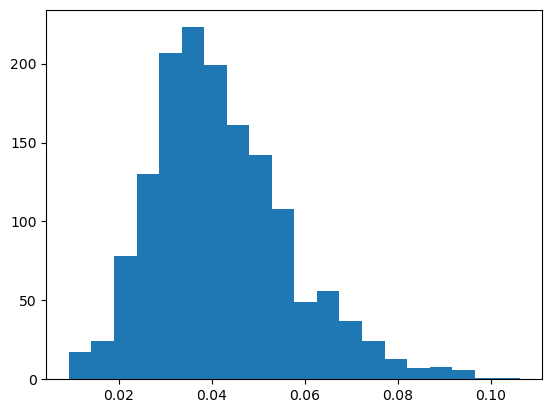

In [32]:
x4_wd = calculate_wasserstein("data/predictions/timesfm/timesfm_solar_winter.npz", season='winter')

In [33]:
# get mean and std of wasserstein distance for x
mean_wd_x = np.mean(x1_wd)
std_wd_x = np.std(x1_wd)

print(f"Mean Wasserstein Distance for Chronos2 Solar Summer: {mean_wd_x:.4f} ± {std_wd_x:.4f}")

# get mean and std of wasserstein distance  for x2
mean_wd_x2 = np.mean(x2_wd)
std_wd_x2 = np.std(x2_wd)

print(f"Mean Wasserstein Distance for Chronos2 Solar Winter: {mean_wd_x2:.4f} ± {std_wd_x2:.4f}")

# get mean and std of wasserstein distance for x3
mean_wd_x3 = np.mean(x3_wd)
std_wd_x3 = np.std(x3_wd)

print(f"Mean Wasserstein Distance for TimesFM Solar Summer: {mean_wd_x3:.4f} ± {std_wd_x3:.4f}")

# get mean and std of wasserstein distance for x4
mean_wd_x4 = np.mean(x4_wd)
std_wd_x4 = np.std(x4_wd)

print(f"Mean Wasserstein Distance for TimesFM Solar Winter: {mean_wd_x4:.4f} ± {std_wd_x4:.4f}")

Mean Wasserstein Distance for Chronos2 Solar Summer: 0.0394 ± 0.0225
Mean Wasserstein Distance for Chronos2 Solar Winter: 0.0174 ± 0.0079
Mean Wasserstein Distance for TimesFM Solar Summer: 0.0674 ± 0.0281
Mean Wasserstein Distance for TimesFM Solar Winter: 0.0420 ± 0.0149


C:\Users\JanderM\AppData\Local\Temp\ipykernel_1044\3533179727.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([x1_wd, x2_wd, x3_wd, x4_wd], labels=models)


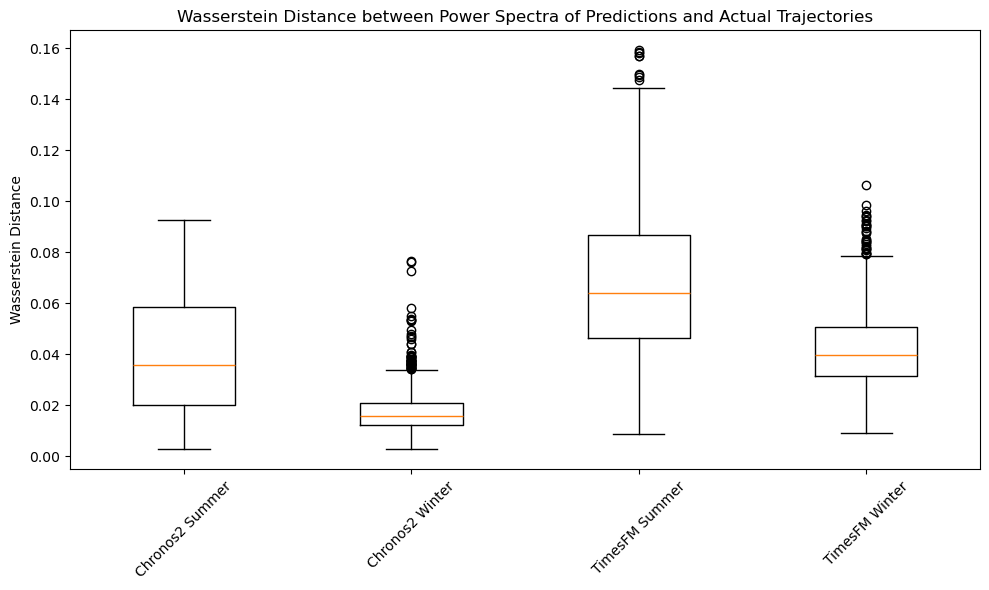

In [34]:
# plot mean and 95% confidence intervals for each model and season as box plots
models = ['Chronos2 Summer', 'Chronos2 Winter', 'TimesFM Summer', 'TimesFM Winter']
plt.figure(figsize=(10, 6))
plt.boxplot([x1_wd, x2_wd, x3_wd, x4_wd], labels=models)
plt.ylabel('Wasserstein Distance')
plt.title('Wasserstein Distance between Power Spectra of Predictions and Actual Trajectories')
plt.xticks(rotation=45)
plt.tight_layout()

In [35]:
# do same for mean and 95% confidence interval of wasserstein distances for each model and season as bar plot with error bars


# calculate 95% confidence intervals for each model and season
ci_x = stats.norm.interval(0.95, loc=mean_wd_x, scale=std_wd_x/np.sqrt(len(x1_wd))) 
ci_x2 = stats.norm.interval(0.95, loc=mean_wd_x2, scale=std_wd_x2/np.sqrt(len(x2_wd))) 
ci_x3 = stats.norm.interval(0.95, loc=mean_wd_x3, scale=std_wd_x3/np.sqrt(len(x3_wd))) 
ci_x4 = stats.norm.interval(0.95, loc=mean_wd_x4, scale=std_wd_x4/np.sqrt(len(x4_wd))) 


print(f"95% CI for Chronos2 Summer: ({ci_x[0]:.4f}, {ci_x[1]:.4f})")
print(f"95% CI for Chronos2 Winter: ({ci_x2[0]:.4f}, {ci_x2[1]:.4f})")
print(f"95% CI for TimesFM Summer: ({ci_x3[0]:.4f}, {ci_x3[1]:.4f})")
print(f"95% CI for TimesFM Winter: ({ci_x4[0]:.4f}, {ci_x4[1]:.4f})")

95% CI for Chronos2 Summer: (0.0384, 0.0403)
95% CI for Chronos2 Winter: (0.0170, 0.0178)
95% CI for TimesFM Summer: (0.0662, 0.0686)
95% CI for TimesFM Winter: (0.0413, 0.0428)


Differences in wasserstein distance holds averaged across all samples.